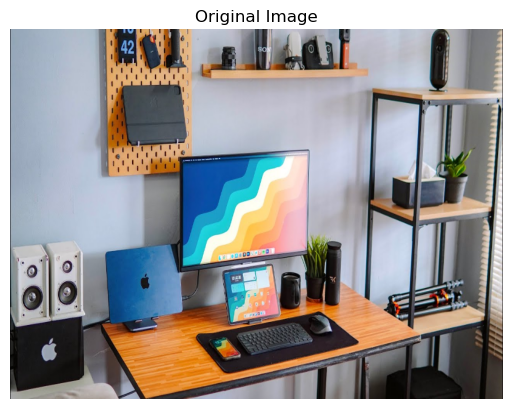

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('objects2.jpg')

if image is None:
    print("Error: Image not found")
else:
    image = cv2.resize(image, (800, 600))

    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")
    plt.show()

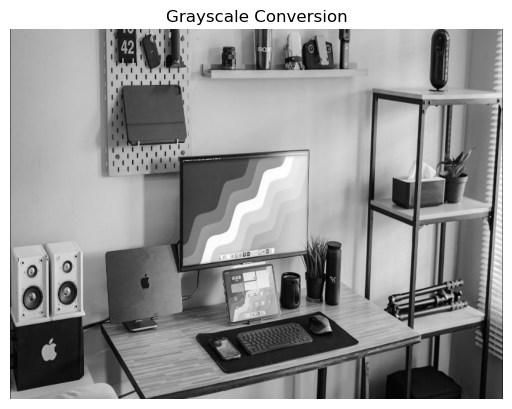

In [2]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Conversion")
plt.axis("off")
plt.show()

In [3]:
import time

start = time.time()

# Your pipeline
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7,7), 0)
edges = cv2.Canny(blur, 50, 100)
dilated = cv2.dilate(edges, None, iterations=1)
eroded = cv2.erode(dilated, None, iterations=1)

contours, _ = cv2.findContours(eroded.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

end = time.time()

inference_time = end - start
latency = inference_time  # same in this case

print("Inference Time:", round(inference_time, 6), "seconds")
print("Latency:", round(latency, 6), "seconds")

Inference Time: 0.122496 seconds
Latency: 0.122496 seconds


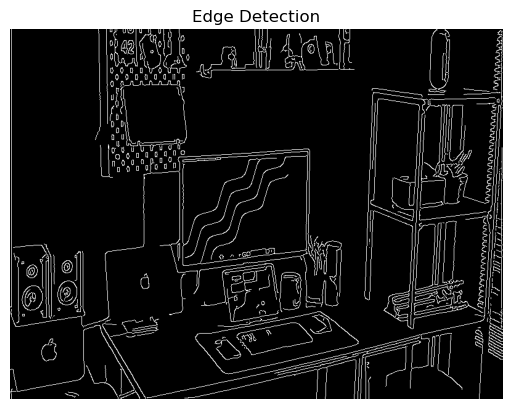

In [4]:
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")
plt.axis("off")
plt.show()

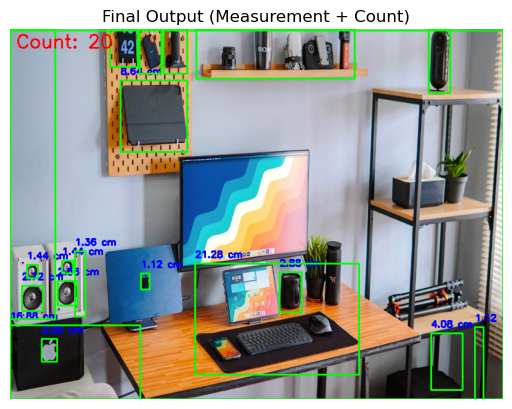

In [5]:
final_img = image.copy()
pixels_per_metric = None
count = 0

for c in contours:
    if cv2.contourArea(c) < 200:
        continue

    count += 1

    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(final_img, (x, y), (x+w, y+h), (0,255,0), 2)

    # reference object (assume first = 2 cm)
    if pixels_per_metric is None:
        pixels_per_metric = w / 2.0

    dimension = w / pixels_per_metric

    cv2.putText(final_img, f"{dimension:.2f} cm",
                (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (255,0,0), 2)

cv2.putText(final_img, f"Count: {count}",
            (10,30),
            cv2.FONT_HERSHEY_SIMPLEX,
            1, (0,0,255), 2)

plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
plt.title("Final Output (Measurement + Count)")
plt.axis("off")
plt.show()